# 问题一：出厂水浊度的影响因素与机器学习分析

本 notebook 从 `data/merged.xlsx` 读取合并后的水厂监测数据，以出厂水浊度 `NTU` 为因变量，依次完成数据检查、主成分分析（PCA）、Random Forest 与 XGBoost 回归、变量重要性、SHAP 解释和相关性分析。

建模只使用同期变量，不构造滞后特征。PCA 用于探索连续变量的整体结构，不作为树模型的输入。模型按时间顺序划分训练集和测试集，并仅在训练段内进行时间序列交叉验证，避免未来信息泄漏。

## 1. 环境与依赖

导入分析所需的库，设置随机种子和统一绘图风格。Notebook 对数据路径进行自动定位，因此从项目根目录或 `codes/` 目录启动均可运行。

In [ ]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from xgboost import XGBRegressor

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
warnings.filterwarnings("ignore", category=FutureWarning)
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.sans-serif"] = ["Arial Unicode MS", "Songti SC", "Heiti TC", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False

print(f"pandas: {pd.__version__}")
print(f"SHAP: {shap.__version__}")

pandas: 3.0.2
SHAP: 0.51.0


## 2. 读取并检查数据

程序依次检查当前目录和父目录中的 `data/merged.xlsx`，输出最终使用的绝对路径。随后合并 `DATE` 与 `TIME` 形成时间戳，按时间排序，并展示数据规模、时间范围、字段类型和缺失率。

In [ ]:
def locate_data_file():
    candidates = [
        Path.cwd() / "data" / "merged.xlsx",
        Path.cwd().parent / "data" / "merged.xlsx",
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate.resolve()
    searched = "\n".join(str(path.resolve()) for path in candidates)
    raise FileNotFoundError(f"未找到 merged.xlsx，已检查：\n{searched}")


DATA_PATH = locate_data_file()
raw_df = pd.read_excel(DATA_PATH, sheet_name="Merged")

time_text = raw_df["TIME"].astype(str).str.split().str[-1]
raw_df["TIMESTAMP"] = pd.to_datetime(
    raw_df["DATE"].astype(str).str.split().str[0] + " " + time_text,
    errors="coerce",
)
raw_df = raw_df.sort_values("TIMESTAMP").reset_index(drop=True)

print(f"数据文件：{DATA_PATH}")
print(f"数据规模：{raw_df.shape[0]:,} 行 × {raw_df.shape[1]} 列")
print(f"时间范围：{raw_df['TIMESTAMP'].min()} 至 {raw_df['TIMESTAMP'].max()}")
print(f"时间戳解析失败数：{raw_df['TIMESTAMP'].isna().sum()}")

data_audit = pd.DataFrame({
    "dtype": raw_df.dtypes.astype(str),
    "missing_count": raw_df.isna().sum(),
    "missing_rate": raw_df.isna().mean(),
    "unique_count": raw_df.nunique(dropna=True),
}).sort_values("missing_rate", ascending=False)
display(raw_df.head())
display(data_audit.style.format({"missing_rate": "{:.2%}"}))

数据文件：/Users/jinyu/workspace/2026亚太杯/data/merged.xlsx
数据规模：5,460 行 × 22 列
时间范围：2025-01-01 07:00:00 至 2026-04-01 05:00:00
时间戳解析失败数：0


,DATE,TIME,RIVER LEVEL,R/W PUMP DUTY,R/W FLOW,R/W NTU,R/W CLR,R/W PH,FILT. NTU,C/W WELL LEVEL,...,CLR,CL2,F/RIDE,ALUM,T/W PUMP DUTY,T/W FLOW,18ML LEVEL,18ML FLOW,REMARKS,TIMESTAMP
0,2025-01-01,07:00:00,6.22,2,45.3,150.0,850.0,7.0,0.04,3.82,...,5.0,1.5,NaN,0.04,"2,4",42.6,NaN,NaN,NaN,2025-01-01 07:00:00
1,2025-01-01,09:00:00,6.34,2,45.2,120.0,830.0,7.0,0.05,3.81,...,5.0,1.5,NaN,0.04,"2,4",42.6,NaN,NaN,NaN,2025-01-01 09:00:00
2,2025-01-01,11:00:00,6.17,2,44.9,82.0,780.0,7.0,0.05,3.81,...,5.0,1.6,NaN,0.04,"2,4",42.7,NaN,NaN,"B/W No.4,6",2025-01-01 11:00:00
3,2025-01-01,13:00:00,5.99,2,44.9,62.0,720.0,7.0,0.05,3.58,...,5.0,1.6,NaN,0.04,"2,4",42.3,NaN,NaN,NaN,2025-01-01 13:00:00
4,2025-01-01,15:00:00,5.83,2,44.5,56.0,641.0,7.0,0.05,3.58,...,5.0,1.6,NaN,0.04,"2,4",42.5,NaN,NaN,NaN,2025-01-01 15:00:00


,dtype,missing_count,missing_rate,unique_count
18ML LEVEL,float64,5460,100.00%,0
18ML FLOW,float64,5460,100.00%,0
REMARKS,str,5237,95.92%,154
F/RIDE,float64,4132,75.68%,16
R/W PUMP DUTY,object,1748,32.01%,8
CL2,float64,1726,31.61%,34
T/W PUMP DUTY,object,1652,30.26%,27
ALUM,float64,1645,30.13%,5
R/W PH,float64,1644,30.11%,3
PH,float64,1644,30.11%,5


## 3. 建模数据与防泄漏预处理

目标变量为 `NTU`。删除目标缺失的记录后，按时间顺序将前 80% 作为训练集、后 20% 作为独立测试集。

模型不使用日期、时间、备注、全空字段及缺失率过高的 `F/RIDE`。连续字段使用训练集的中位数填补；泵组等类别字段使用训练集众数填补并独热编码。所有步骤封装在 `Pipeline` 中，测试集不会参与填补、编码或超参数选择。

In [ ]:
TARGET = "NTU"
EXPLICIT_EXCLUSIONS = {"DATE", "TIME", "TIMESTAMP", "REMARKS", "F/RIDE"}
all_empty_columns = set(raw_df.columns[raw_df.isna().all()])
excluded_columns = EXPLICIT_EXCLUSIONS | all_empty_columns | {TARGET}

model_df = raw_df.loc[raw_df[TARGET].notna()].copy()
feature_columns = [
    column for column in model_df.columns if column not in excluded_columns
]
X = model_df[feature_columns].copy()
y = model_df[TARGET].astype(float)
timestamps = model_df["TIMESTAMP"]

numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = [
    column for column in feature_columns if column not in numeric_features
]
for column in categorical_features:
    X[column] = X[column].map(
        lambda value: str(value) if pd.notna(value) else np.nan
    )

split_index = int(len(model_df) * 0.8)
X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]
time_train, time_test = timestamps.iloc[:split_index], timestamps.iloc[split_index:]

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
])
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])
preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", numeric_pipeline, numeric_features),
        ("categorical", categorical_pipeline, categorical_features),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

print(f"删除的全空字段：{sorted(all_empty_columns)}")
print(f"连续特征（{len(numeric_features)} 个）：{numeric_features}")
print(f"类别特征（{len(categorical_features)} 个）：{categorical_features}")
print(f"训练集：{len(X_train):,} 条，{time_train.min()} 至 {time_train.max()}")
print(f"测试集：{len(X_test):,} 条，{time_test.min()} 至 {time_test.max()}")
assert time_train.max() < time_test.min(), "训练集和测试集的时间顺序异常"
assert X_train.index.intersection(X_test.index).empty, "训练集与测试集发生重叠" 

删除的全空字段：['18ML FLOW', '18ML LEVEL']
连续特征（12 个）：['RIVER LEVEL', 'R/W FLOW', 'R/W NTU', 'R/W CLR', 'R/W PH', 'FILT. NTU', 'C/W WELL LEVEL', 'PH', 'CLR', 'CL2', 'ALUM', 'T/W FLOW']
类别特征（2 个）：['R/W PUMP DUTY', 'T/W PUMP DUTY']
训练集：4,095 条，2025-01-01 07:00:00 至 2025-12-08 21:00:00
测试集：1,024 条，2025-12-08 23:00:00 至 2026-04-01 05:00:00


## 4. 主成分分析（PCA）

PCA 仅使用非全空的连续解释变量。先以中位数填补缺失值，再标准化以消除量纲影响。碎石图展示各主成分及累计解释方差；二维得分图按 `NTU` 着色；载荷表用于判断每个主成分主要由哪些原始指标构成。

,component,explained_variance_ratio,cumulative_variance_ratio
0,PC1,20.59%,20.59%
1,PC2,16.29%,36.88%
2,PC3,9.86%,46.74%
3,PC4,8.90%,55.64%
4,PC5,8.63%,64.27%
5,PC6,7.80%,72.07%
6,PC7,7.36%,79.43%
7,PC8,6.39%,85.81%
8,PC9,6.21%,92.03%
9,PC10,4.79%,96.81%


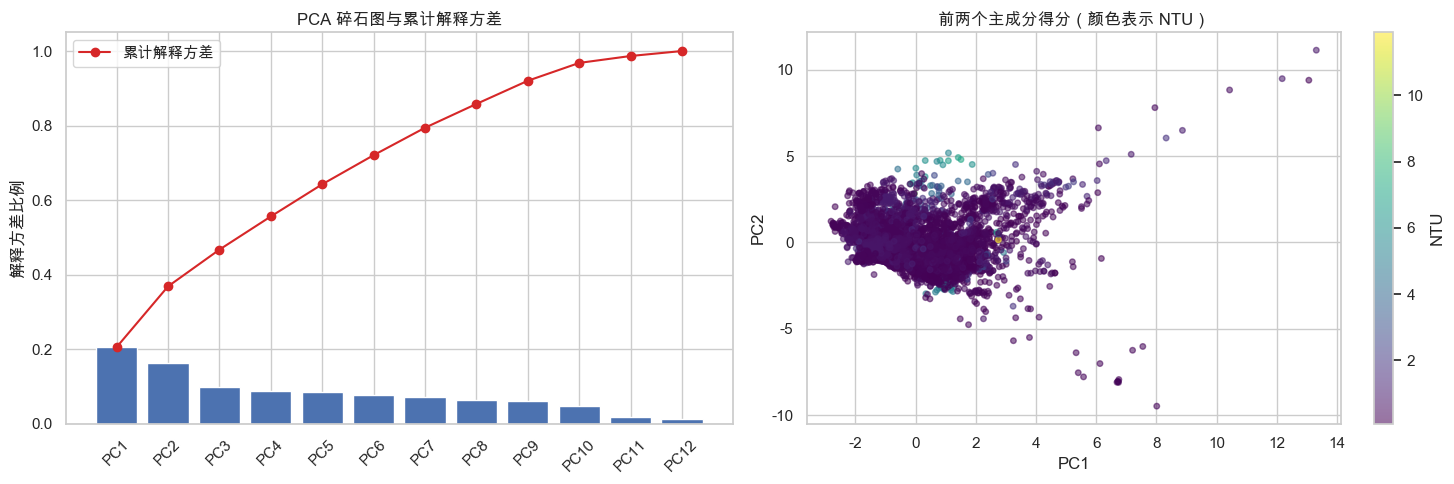

,PC1,PC2,PC3,PC4,PC5
RIVER LEVEL,0.444,0.090,0.032,0.077,0.033
R/W FLOW,-0.394,0.476,-0.043,0.077,0.091
R/W NTU,0.471,0.350,-0.029,-0.150,0.108
R/W CLR,0.461,0.296,0.029,-0.110,0.177
R/W PH,0.149,-0.181,0.230,0.267,0.044
FILT. NTU,0.124,0.231,-0.396,0.437,-0.157
C/W WELL LEVEL,-0.109,0.167,0.460,-0.532,0.176
PH,0.019,-0.104,-0.396,-0.217,0.683
CLR,-0.024,0.093,0.226,0.536,0.540
CL2,-0.051,-0.290,0.397,0.228,0.263


PC1 绝对载荷最高变量：R/W NTU, R/W CLR, RIVER LEVEL, R/W FLOW, T/W FLOW
PC2 绝对载荷最高变量：T/W FLOW, R/W FLOW, R/W NTU, ALUM, R/W CLR
PC3 绝对载荷最高变量：C/W WELL LEVEL, ALUM, CL2, PH, FILT. NTU
PC4 绝对载荷最高变量：CLR, C/W WELL LEVEL, FILT. NTU, R/W PH, CL2
PC5 绝对载荷最高变量：PH, CLR, CL2, ALUM, R/W CLR


In [ ]:
pca_features = [
    column for column in numeric_features
    if model_df[column].nunique(dropna=True) > 1
]
pca_imputer = SimpleImputer(strategy="median")
pca_scaler = StandardScaler()
pca_input = pca_scaler.fit_transform(
    pca_imputer.fit_transform(model_df[pca_features])
)
pca = PCA()
pca_scores = pca.fit_transform(pca_input)

explained = pd.DataFrame({
    "component": [f"PC{i + 1}" for i in range(pca.n_components_)],
    "explained_variance_ratio": pca.explained_variance_ratio_,
    "cumulative_variance_ratio": np.cumsum(pca.explained_variance_ratio_),
})
display(explained.style.format({
    "explained_variance_ratio": "{:.2%}",
    "cumulative_variance_ratio": "{:.2%}",
}))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].bar(explained["component"], explained["explained_variance_ratio"])
axes[0].plot(
    explained["component"],
    explained["cumulative_variance_ratio"],
    color="tab:red",
    marker="o",
    label="累计解释方差",
)
axes[0].set_title("PCA 碎石图与累计解释方差")
axes[0].set_ylabel("解释方差比例")
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend()

scatter = axes[1].scatter(
    pca_scores[:, 0],
    pca_scores[:, 1],
    c=model_df[TARGET],
    cmap="viridis",
    alpha=0.55,
    s=16,
)
axes[1].set_title("前两个主成分得分（颜色表示 NTU）")
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
fig.colorbar(scatter, ax=axes[1], label="NTU")
plt.tight_layout()
plt.show()

loading_count = min(5, pca.n_components_)
loadings = pd.DataFrame(
    pca.components_[:loading_count].T,
    index=pca_features,
    columns=[f"PC{i + 1}" for i in range(loading_count)],
)
display(loadings.style.background_gradient(cmap="coolwarm", axis=None).format("{:.3f}"))

for component in loadings.columns:
    top_variables = loadings[component].abs().nlargest(5).index
    print(f"{component} 绝对载荷最高变量：{', '.join(top_variables)}")

## 5. Random Forest 回归

训练段内部采用 4 折扩展窗口 `TimeSeriesSplit`，通过小型随机参数搜索最小化 RMSE。最后仅在独立测试时间段上报告 MAE、RMSE 和决定系数 $R^2$。

Fitting 4 folds for each of 15 candidates, totalling 60 fits
最优参数： {'model__n_estimators': 300, 'model__min_samples_split': 2, 'model__min_samples_leaf': 2, 'model__max_features': 1.0, 'model__max_depth': 8}


,MAE,RMSE,R2
Random Forest,0.2444,0.5811,-3.3174


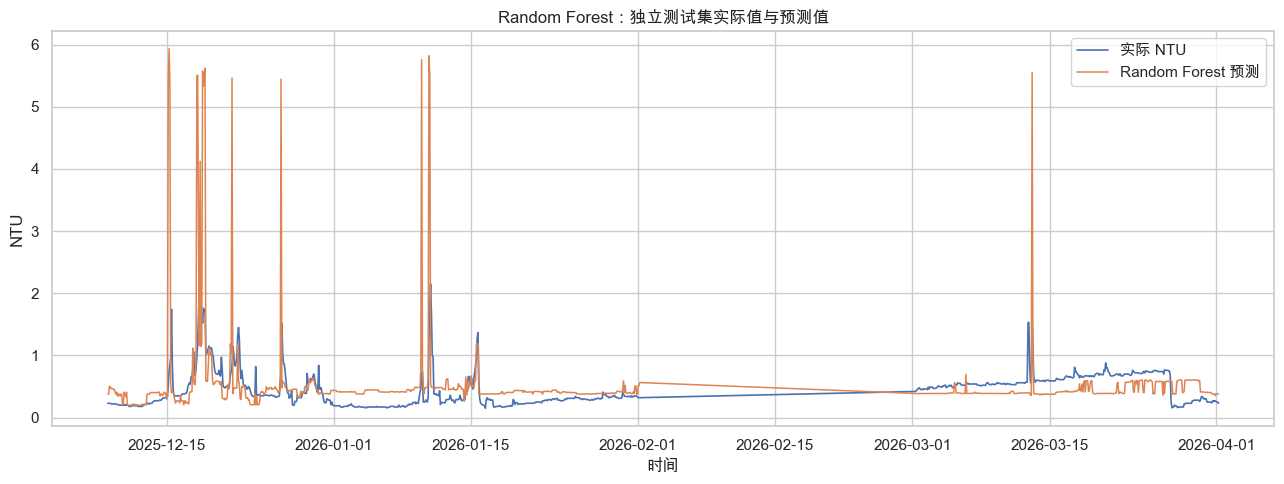

In [ ]:
time_cv = TimeSeriesSplit(n_splits=4)

rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])
rf_params = {
    "model__n_estimators": [300, 500, 700],
    "model__max_depth": [None, 8, 14, 20],
    "model__min_samples_split": [2, 5, 10],
    "model__min_samples_leaf": [1, 2, 4],
    "model__max_features": ["sqrt", 0.7, 1.0],
}
rf_search = RandomizedSearchCV(
    rf_pipeline,
    param_distributions=rf_params,
    n_iter=15,
    scoring="neg_root_mean_squared_error",
    cv=time_cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    refit=True,
    verbose=1,
)
rf_search.fit(X_train, y_train)
rf_model = rf_search.best_estimator_
rf_predictions = rf_model.predict(X_test)

def regression_metrics(actual, predicted):
    return {
        "MAE": mean_absolute_error(actual, predicted),
        "RMSE": mean_squared_error(actual, predicted) ** 0.5,
        "R2": r2_score(actual, predicted),
    }

rf_metrics = regression_metrics(y_test, rf_predictions)
print("最优参数：", rf_search.best_params_)
display(pd.DataFrame([rf_metrics], index=["Random Forest"]).style.format("{:.4f}"))

plt.figure(figsize=(13, 5))
plt.plot(time_test, y_test, label="实际 NTU", linewidth=1.2)
plt.plot(time_test, rf_predictions, label="Random Forest 预测", linewidth=1.1)
plt.title("Random Forest：独立测试集实际值与预测值")
plt.xlabel("时间")
plt.ylabel("NTU")
plt.legend()
plt.tight_layout()
plt.show()

## 6. XGBoost 回归

XGBoost 使用与 Random Forest 完全相同的时间切分、交叉验证折和评价指标。搜索学习率、树深、子采样比例和列采样比例等参数，以保证模型比较公平。

Fitting 4 folds for each of 15 candidates, totalling 60 fits
最优参数： {'model__subsample': 0.7, 'model__reg_lambda': 10.0, 'model__n_estimators': 700, 'model__min_child_weight': 1, 'model__max_depth': 3, 'model__learning_rate': 0.02, 'model__colsample_bytree': 1.0}


,MAE,RMSE,R2
XGBoost,0.2303,0.4738,-1.8699


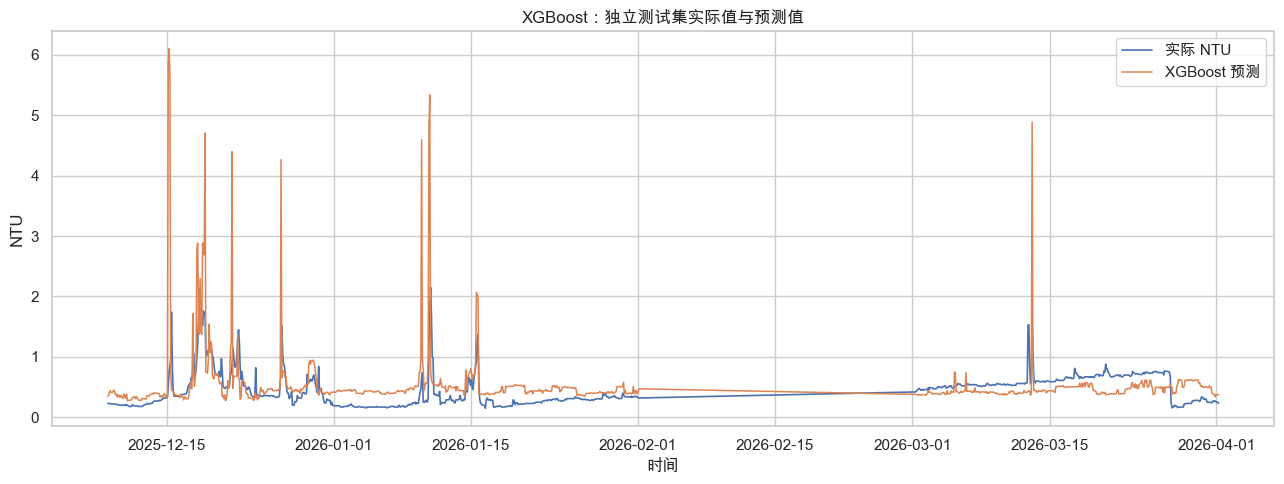

In [ ]:
xgb_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBRegressor(
        objective="reg:squarederror",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        tree_method="hist",
    )),
])
xgb_params = {
    "model__n_estimators": [300, 500, 700],
    "model__learning_rate": [0.02, 0.05, 0.1],
    "model__max_depth": [3, 5, 7],
    "model__min_child_weight": [1, 3, 6],
    "model__subsample": [0.7, 0.85, 1.0],
    "model__colsample_bytree": [0.7, 0.85, 1.0],
    "model__reg_lambda": [1.0, 5.0, 10.0],
}
xgb_search = RandomizedSearchCV(
    xgb_pipeline,
    param_distributions=xgb_params,
    n_iter=15,
    scoring="neg_root_mean_squared_error",
    cv=time_cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    refit=True,
    verbose=1,
)
xgb_search.fit(X_train, y_train)
xgb_model = xgb_search.best_estimator_
xgb_predictions = xgb_model.predict(X_test)
xgb_metrics = regression_metrics(y_test, xgb_predictions)

print("最优参数：", xgb_search.best_params_)
display(pd.DataFrame([xgb_metrics], index=["XGBoost"]).style.format("{:.4f}"))

plt.figure(figsize=(13, 5))
plt.plot(time_test, y_test, label="实际 NTU", linewidth=1.2)
plt.plot(time_test, xgb_predictions, label="XGBoost 预测", linewidth=1.1)
plt.title("XGBoost：独立测试集实际值与预测值")
plt.xlabel("时间")
plt.ylabel("NTU")
plt.legend()
plt.tight_layout()
plt.show()

## 7. 模型性能比较

汇总两个模型在同一独立测试集上的指标。MAE 和 RMSE 越小越好，$R^2$ 越大越好。散点图中的虚线代表理想预测，用于观察系统性高估、低估和极端值拟合情况。

,MAE,RMSE,R2
XGBoost,0.2303,0.4738,-1.8699
Random Forest,0.2444,0.5811,-3.3174


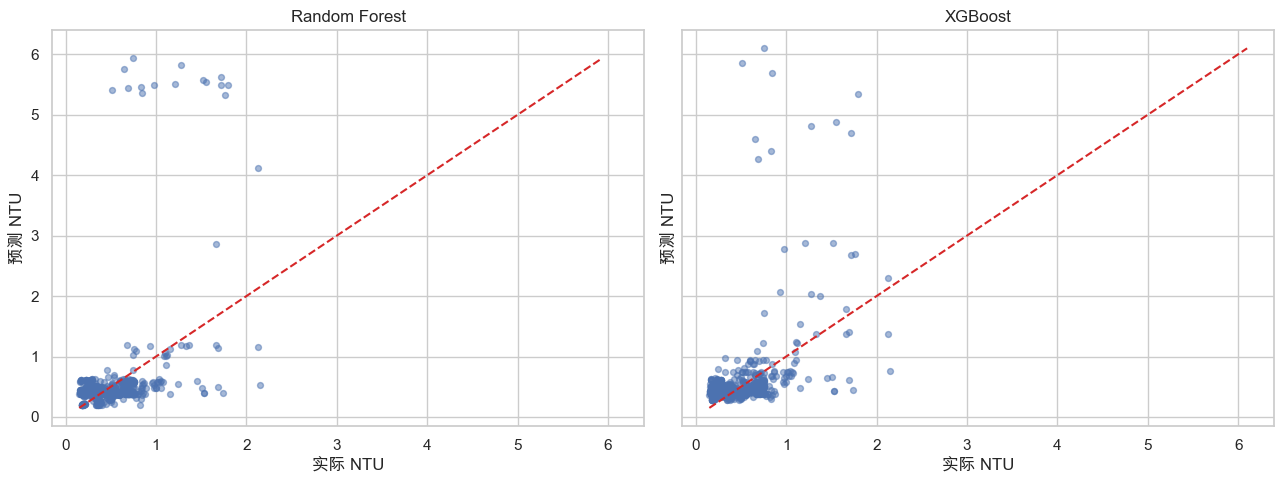

In [ ]:
metrics_table = pd.DataFrame(
    [rf_metrics, xgb_metrics],
    index=["Random Forest", "XGBoost"],
).sort_values("RMSE")
display(metrics_table.style.format("{:.4f}").highlight_min(
    subset=["MAE", "RMSE"], color="#c6efce"
).highlight_max(subset=["R2"], color="#c6efce"))

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=True, sharey=True)
for axis, name, predictions in [
    (axes[0], "Random Forest", rf_predictions),
    (axes[1], "XGBoost", xgb_predictions),
]:
    axis.scatter(y_test, predictions, alpha=0.5, s=18)
    limits = [
        min(y_test.min(), predictions.min()),
        max(y_test.max(), predictions.max()),
    ]
    axis.plot(limits, limits, "--", color="tab:red")
    axis.set_title(name)
    axis.set_xlabel("实际 NTU")
    axis.set_ylabel("预测 NTU")
plt.tight_layout()
plt.show()

## 8. 原始变量重要性

树模型的重要性首先对应预处理后的列。对于类别变量产生的多个独热列，本节将其重要性求和并聚合回原始字段，从而得到可直接解释的水质和工艺变量排名。

,source_feature,importance
4,FILT. NTU,0.5703
3,CLR,0.2724
2,CL2,0.0420
11,RIVER LEVEL,0.0267
12,T/W FLOW,0.0242
7,R/W FLOW,0.0198
1,C/W WELL LEVEL,0.0156
13,T/W PUMP DUTY,0.0127
6,R/W CLR,0.0088
8,R/W NTU,0.0049


,source_feature,importance
3,CLR,0.3712
4,FILT. NTU,0.2645
13,T/W PUMP DUTY,0.1033
10,R/W PUMP DUTY,0.0450
2,CL2,0.0359
6,R/W CLR,0.0326
12,T/W FLOW,0.0317
7,R/W FLOW,0.0273
11,RIVER LEVEL,0.0250
1,C/W WELL LEVEL,0.0168


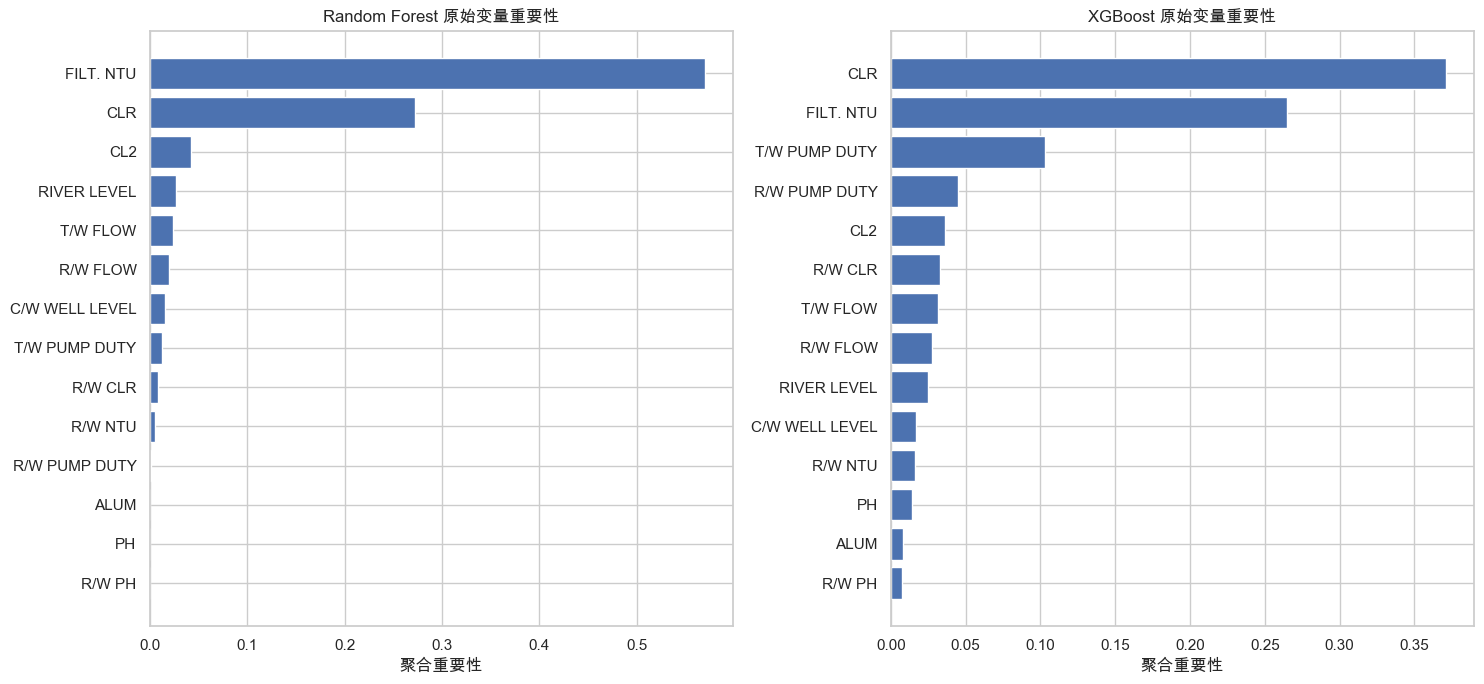

In [ ]:
def transformed_feature_metadata(fitted_pipeline):
    fitted_preprocessor = fitted_pipeline.named_steps["preprocessor"]
    transformed_names = fitted_preprocessor.get_feature_names_out().tolist()
    source_names = list(numeric_features)
    if categorical_features:
        encoder = (
            fitted_preprocessor.named_transformers_["categorical"]
            .named_steps["onehot"]
        )
        for column, categories in zip(categorical_features, encoder.categories_):
            source_names.extend([column] * len(categories))
    if len(transformed_names) != len(source_names):
        raise ValueError("转换后特征与原始字段映射长度不一致")
    return transformed_names, source_names


def aggregated_tree_importance(fitted_pipeline):
    transformed_names, source_names = transformed_feature_metadata(fitted_pipeline)
    importances = fitted_pipeline.named_steps["model"].feature_importances_
    detail = pd.DataFrame({
        "transformed_feature": transformed_names,
        "source_feature": source_names,
        "importance": importances,
    })
    aggregated = (
        detail.groupby("source_feature", as_index=False)["importance"]
        .sum()
        .sort_values("importance", ascending=False)
    )
    return aggregated, detail


rf_importance, rf_importance_detail = aggregated_tree_importance(rf_model)
xgb_importance, xgb_importance_detail = aggregated_tree_importance(xgb_model)
display(rf_importance.head(15).style.format({"importance": "{:.4f}"}))
display(xgb_importance.head(15).style.format({"importance": "{:.4f}"}))

fig, axes = plt.subplots(1, 2, figsize=(15, 7))
for axis, title, table in [
    (axes[0], "Random Forest 原始变量重要性", rf_importance),
    (axes[1], "XGBoost 原始变量重要性", xgb_importance),
]:
    top = table.head(15).sort_values("importance")
    axis.barh(top["source_feature"], top["importance"])
    axis.set_title(title)
    axis.set_xlabel("聚合重要性")
plt.tight_layout()
plt.show()

## 9. SHAP 模型解释

分别使用 TreeExplainer 解释 Random Forest 和 XGBoost。为控制运行时间，从测试集按时间均匀抽取最多 500 条记录。条形图将平均绝对 SHAP 值聚合回原始字段；beeswarm 图保留转换后特征，用于观察变量取值对预测的推动方向和影响分布。

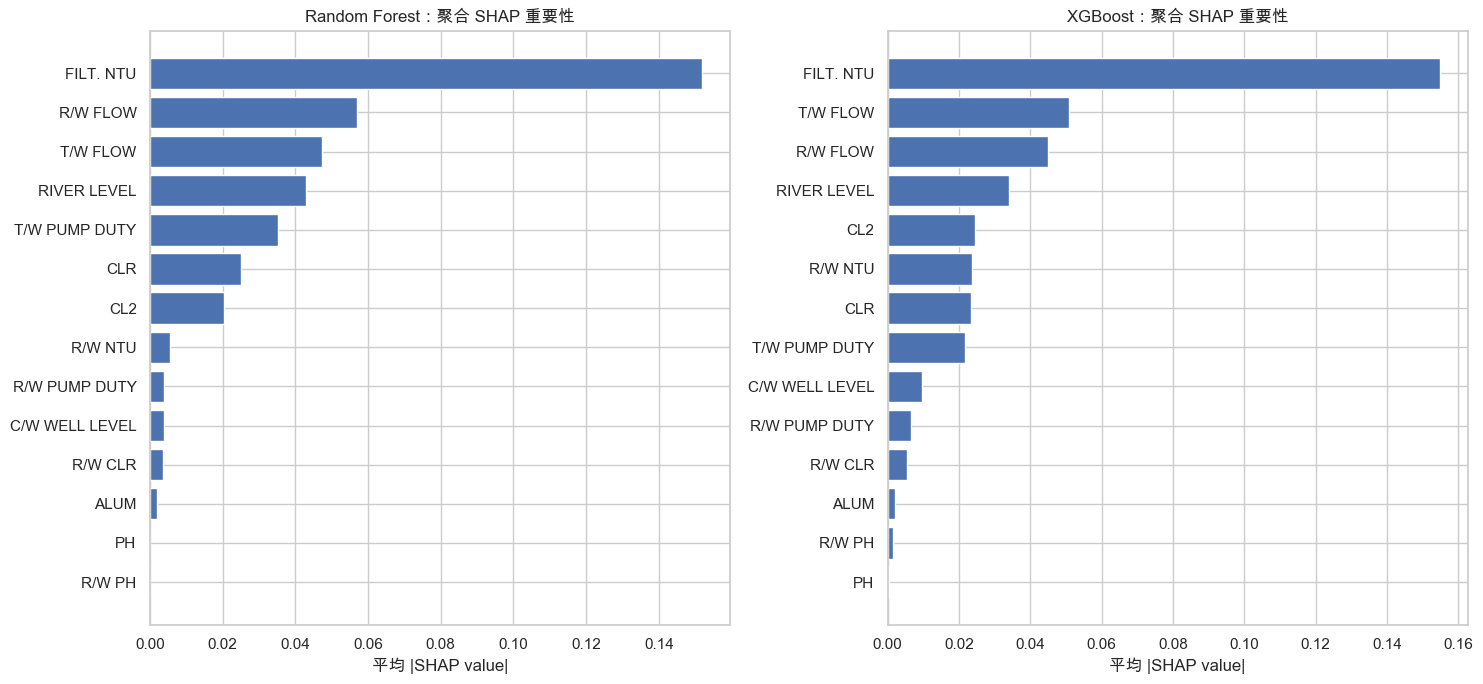


Random Forest SHAP summary


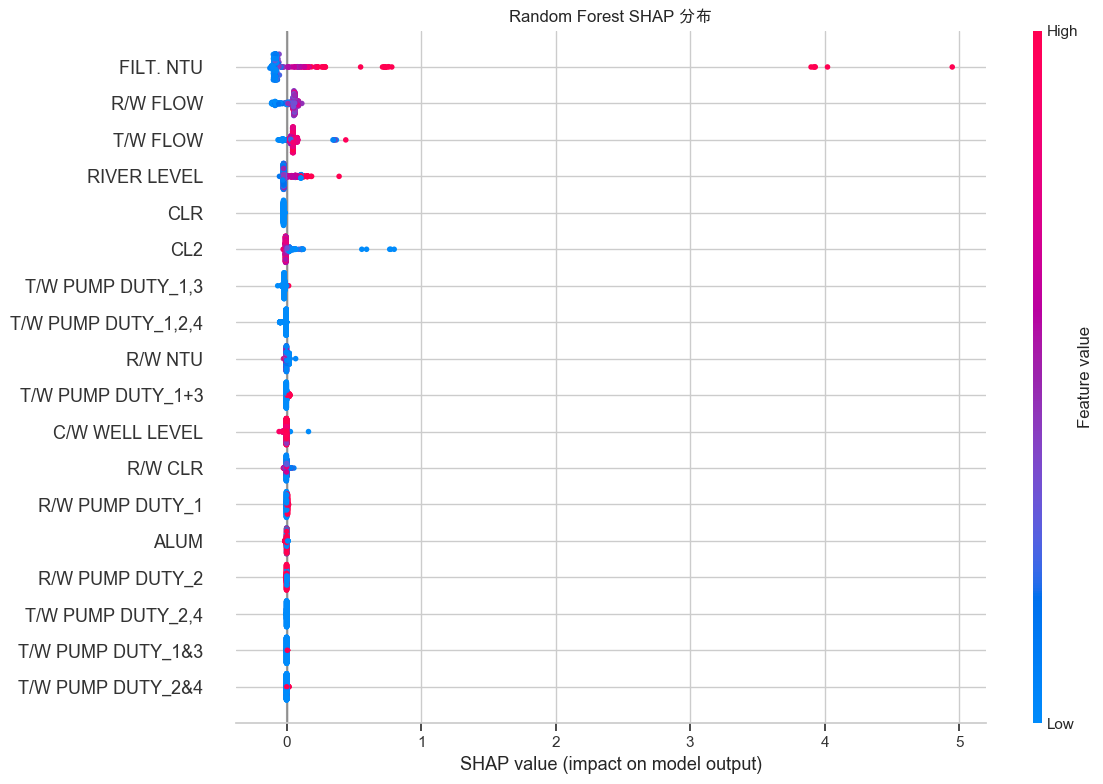

,source_feature,mean_abs_shap
4,FILT. NTU,0.1519
7,R/W FLOW,0.0570
12,T/W FLOW,0.0473
11,RIVER LEVEL,0.0430
13,T/W PUMP DUTY,0.0353
3,CLR,0.0250
2,CL2,0.0204
8,R/W NTU,0.0055
10,R/W PUMP DUTY,0.0040
1,C/W WELL LEVEL,0.0038



XGBoost SHAP summary


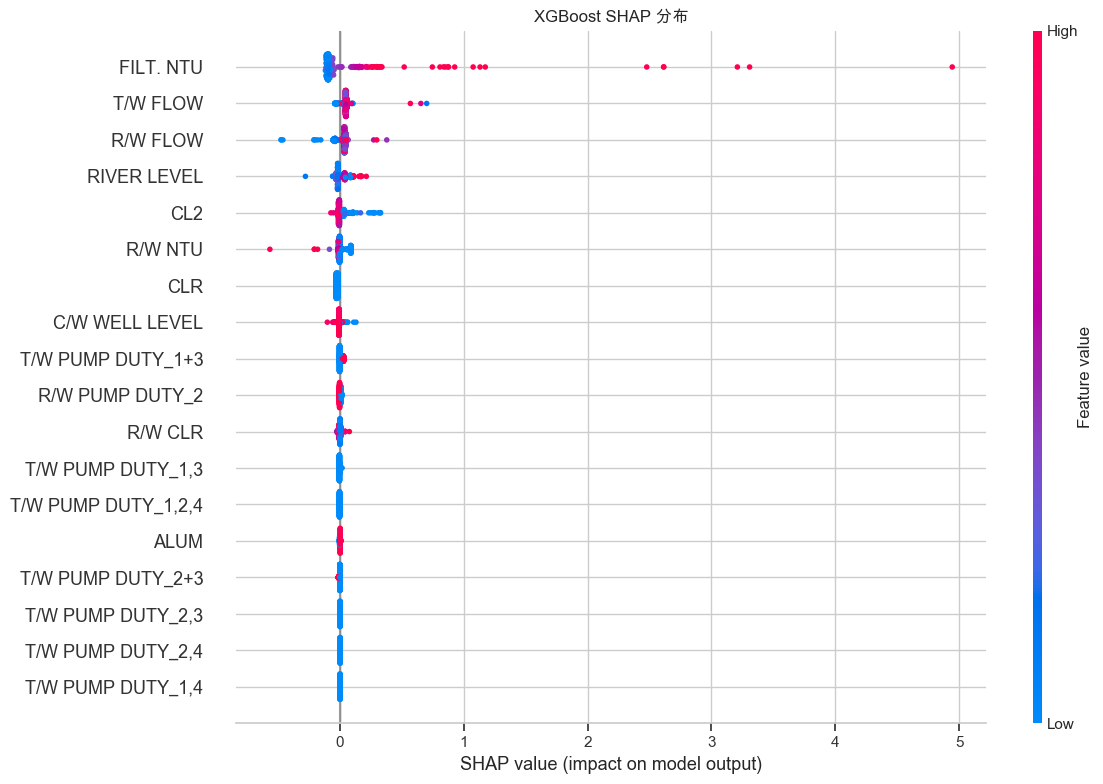

,source_feature,mean_abs_shap
4,FILT. NTU,0.1549
12,T/W FLOW,0.0508
7,R/W FLOW,0.0451
11,RIVER LEVEL,0.0340
2,CL2,0.0246
8,R/W NTU,0.0237
3,CLR,0.0234
13,T/W PUMP DUTY,0.0218
1,C/W WELL LEVEL,0.0097
10,R/W PUMP DUTY,0.0065


In [ ]:
def compute_shap_results(name, fitted_pipeline, X_source, max_samples=500):
    sample_positions = np.linspace(
        0,
        len(X_source) - 1,
        min(max_samples, len(X_source)),
        dtype=int,
    )
    X_sample = X_source.iloc[sample_positions]
    fitted_preprocessor = fitted_pipeline.named_steps["preprocessor"]
    tree_model = fitted_pipeline.named_steps["model"]
    transformed_names, source_names = transformed_feature_metadata(fitted_pipeline)
    transformed_sample = fitted_preprocessor.transform(X_sample)

    explainer = shap.TreeExplainer(tree_model)
    shap_values = explainer.shap_values(transformed_sample)
    if isinstance(shap_values, list):
        shap_values = shap_values[0]
    shap_values = np.asarray(shap_values)

    global_detail = pd.DataFrame({
        "transformed_feature": transformed_names,
        "source_feature": source_names,
        "mean_abs_shap": np.abs(shap_values).mean(axis=0),
    })
    global_aggregated = (
        global_detail.groupby("source_feature", as_index=False)["mean_abs_shap"]
        .sum()
        .sort_values("mean_abs_shap", ascending=False)
    )
    return {
        "name": name,
        "values": shap_values,
        "data": transformed_sample,
        "feature_names": transformed_names,
        "aggregated": global_aggregated,
    }


rf_shap = compute_shap_results("Random Forest", rf_model, X_test)
xgb_shap = compute_shap_results("XGBoost", xgb_model, X_test)

fig, axes = plt.subplots(1, 2, figsize=(15, 7))
for axis, result in zip(axes, [rf_shap, xgb_shap]):
    top = result["aggregated"].head(15).sort_values("mean_abs_shap")
    axis.barh(top["source_feature"], top["mean_abs_shap"])
    axis.set_title(f"{result['name']}：聚合 SHAP 重要性")
    axis.set_xlabel("平均 |SHAP value|")
plt.tight_layout()
plt.show()

for result in [rf_shap, xgb_shap]:
    print(f"\n{result['name']} SHAP summary")
    shap.summary_plot(
        result["values"],
        result["data"],
        feature_names=result["feature_names"],
        plot_type="dot",
        max_display=18,
        plot_size=(12, 8),
        color_bar_label="Feature value",
        show=False,
    )
    plt.title(f"{result['name']} SHAP 分布")
    plt.xlabel("SHAP value (impact on model output)")
    plt.axvline(0, color="gray", linewidth=1, alpha=0.8)
    plt.tight_layout()
    plt.show()
    display(result["aggregated"].head(15).style.format({"mean_abs_shap": "{:.4f}"}))

## 10. Pearson 与 Spearman 相关性分析

相关性分析使用原始数值字段并保留 `NTU`。全空字段无法计算相关系数，因此自动排除；`F/RIDE` 虽然不参与建模，但其有效观测仍纳入成对相关计算。

Pearson 衡量线性相关，Spearman 基于秩衡量单调相关，对偏态分布和极端值更稳健。相关不代表因果，且同期相关无法说明水处理过程中的时滞作用。

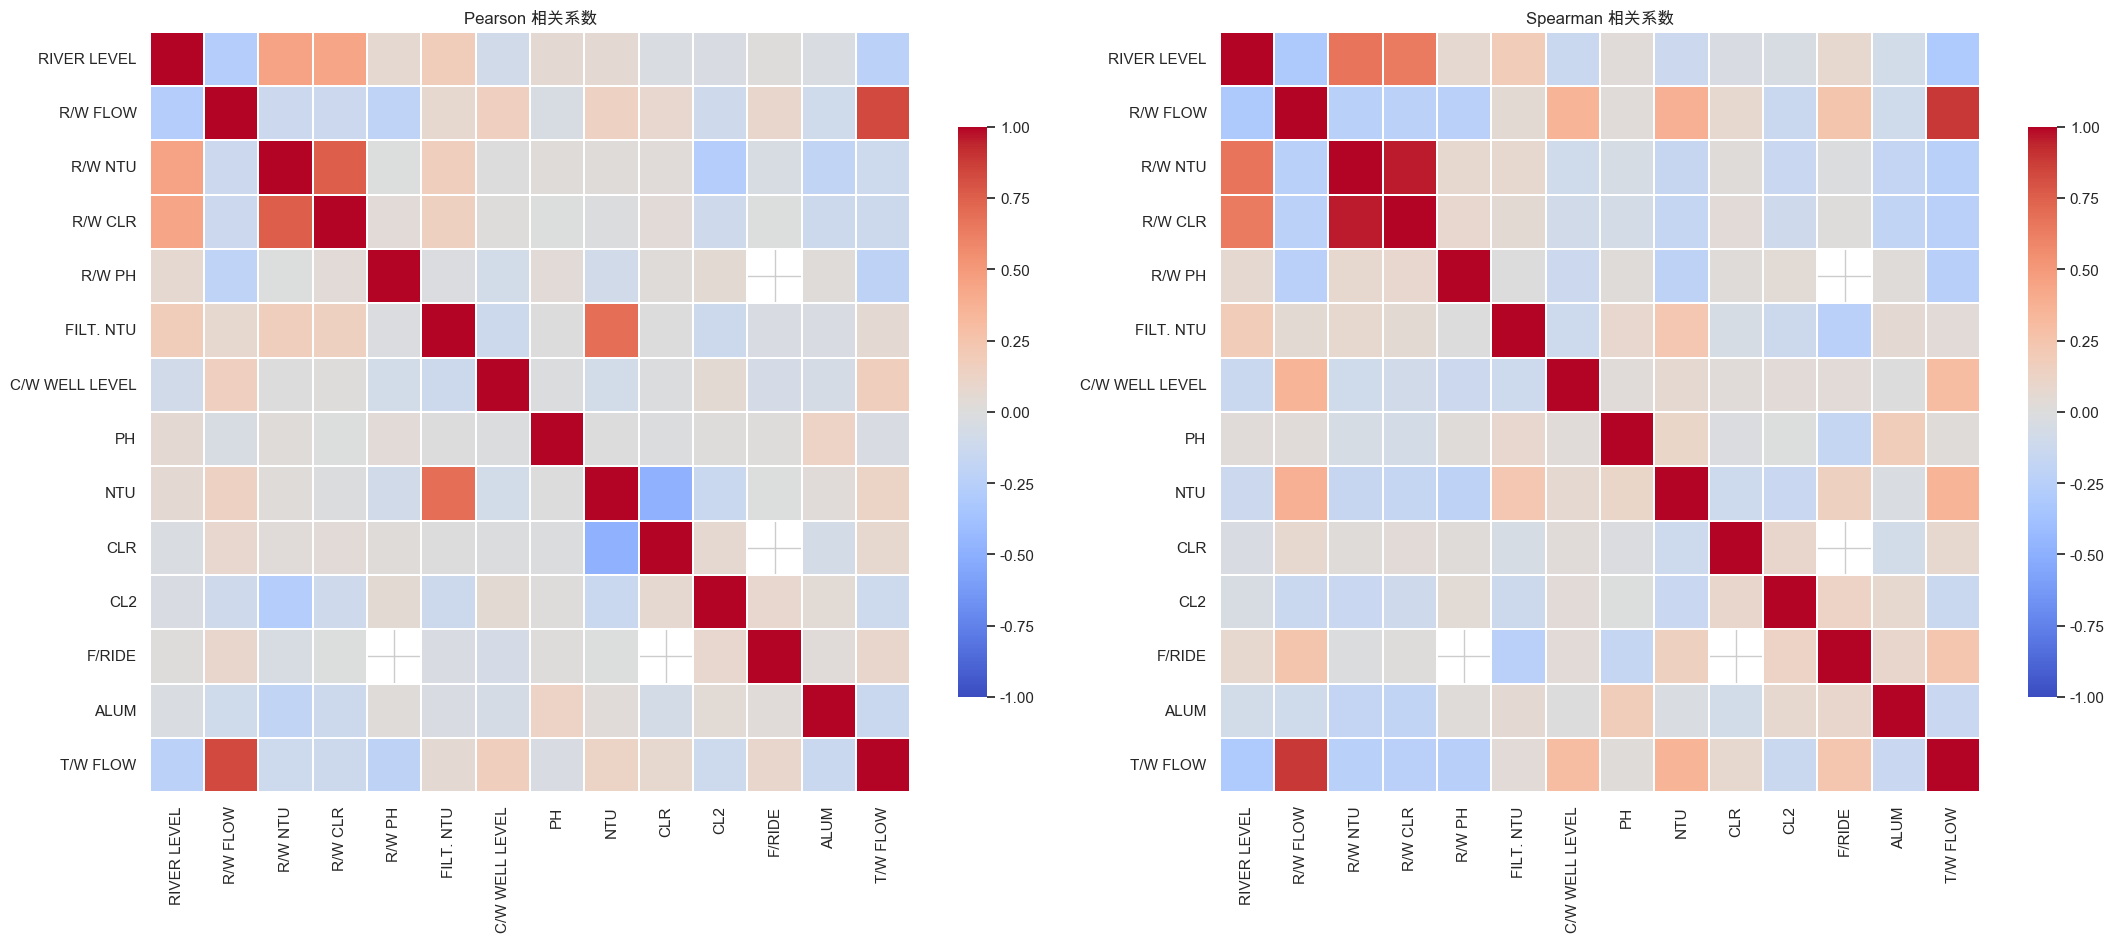

与 NTU 的 Pearson 相关性：


,correlation,absolute_correlation
FILT. NTU,0.6947,0.6947
CLR,-0.4827,0.4827
R/W FLOW,0.1370,0.1370
CL2,-0.1358,0.1358
T/W FLOW,0.1177,0.1177
R/W PH,-0.0897,0.0897
C/W WELL LEVEL,-0.0824,0.0824
RIVER LEVEL,0.0617,0.0617
ALUM,0.0252,0.0252
R/W NTU,0.0230,0.0230


与 NTU 的 Spearman 相关性：


,correlation,absolute_correlation
R/W FLOW,0.3771,0.3771
T/W FLOW,0.3519,0.3519
FILT. NTU,0.2303,0.2303
R/W PH,-0.2118,0.2118
R/W CLR,-0.1695,0.1695
R/W NTU,-0.1574,0.1574
F/RIDE,0.1530,0.1530
CL2,-0.1424,0.1424
RIVER LEVEL,-0.1287,0.1287
CLR,-0.1100,0.1100


In [ ]:
correlation_columns = [
    column for column in raw_df.select_dtypes(include=np.number).columns
    if not raw_df[column].isna().all()
]
correlation_data = raw_df[correlation_columns]
pearson_corr = correlation_data.corr(method="pearson", min_periods=30)
spearman_corr = correlation_data.corr(method="spearman", min_periods=30)

fig, axes = plt.subplots(1, 2, figsize=(22, 9))
for axis, title, matrix in [
    (axes[0], "Pearson 相关系数", pearson_corr),
    (axes[1], "Spearman 相关系数", spearman_corr),
]:
    sns.heatmap(
        matrix,
        cmap="coolwarm",
        center=0,
        vmin=-1,
        vmax=1,
        square=True,
        linewidths=0.3,
        cbar_kws={"shrink": 0.75},
        ax=axis,
    )
    axis.set_title(title)
plt.tight_layout()
plt.show()

def target_correlations(matrix, target=TARGET):
    result = matrix[target].drop(index=target).dropna().to_frame("correlation")
    result["absolute_correlation"] = result["correlation"].abs()
    return result.sort_values("absolute_correlation", ascending=False)

pearson_target = target_correlations(pearson_corr)
spearman_target = target_correlations(spearman_corr)
print("与 NTU 的 Pearson 相关性：")
display(pearson_target.style.format("{:.4f}"))
print("与 NTU 的 Spearman 相关性：")
display(spearman_target.style.format("{:.4f}"))

assert np.allclose(np.diag(pearson_corr), 1.0, equal_nan=False)
assert np.allclose(np.diag(spearman_corr), 1.0, equal_nan=False)
assert pearson_corr.equals(pearson_corr.T)
assert spearman_corr.equals(spearman_corr.T)

## 11. 结果摘要

本节自动汇总测试集表现最佳的模型，以及两种模型重要性和 SHAP 排名靠前的原始变量。最终论文解释应结合 PCA 载荷、相关性、树模型重要性和 SHAP 方向综合判断，避免仅凭单一指标作因果推断。

In [ ]:
best_model_name = metrics_table["RMSE"].idxmin()
summary = pd.DataFrame({
    "分析项目": [
        "测试集 RMSE 最优模型",
        "Random Forest 重要性前三",
        "XGBoost 重要性前三",
        "Random Forest SHAP 前三",
        "XGBoost SHAP 前三",
        "Pearson 与 NTU 绝对相关前三",
        "Spearman 与 NTU 绝对相关前三",
    ],
    "结果": [
        f"{best_model_name}（RMSE={metrics_table.loc[best_model_name, 'RMSE']:.4f}）",
        ", ".join(rf_importance.head(3)["source_feature"]),
        ", ".join(xgb_importance.head(3)["source_feature"]),
        ", ".join(rf_shap["aggregated"].head(3)["source_feature"]),
        ", ".join(xgb_shap["aggregated"].head(3)["source_feature"]),
        ", ".join(pearson_target.head(3).index),
        ", ".join(spearman_target.head(3).index),
    ],
})
display(summary)
print("注意：上述结果反映同期统计关联和模型贡献，不等同于因果关系或最优时滞。")

,分析项目,结果
0,测试集 RMSE 最优模型,XGBoost（RMSE=0.4738）
1,Random Forest 重要性前三,"FILT. NTU, CLR, CL2"
2,XGBoost 重要性前三,"CLR, FILT. NTU, T/W PUMP DUTY"
3,Random Forest SHAP 前三,"FILT. NTU, R/W FLOW, T/W FLOW"
4,XGBoost SHAP 前三,"FILT. NTU, T/W FLOW, R/W FLOW"
5,Pearson 与 NTU 绝对相关前三,"FILT. NTU, CLR, R/W FLOW"
6,Spearman 与 NTU 绝对相关前三,"R/W FLOW, T/W FLOW, FILT. NTU"


注意：上述结果反映同期统计关联和模型贡献，不等同于因果关系或最优时滞。


## 12.Lag-correlation analysis

In [4]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 输出文件夹
OUTPUT_DIR = Path("outputs/problem1")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# 自动寻找 merged.xlsx
possible_paths = [
    Path("data/merged.xlsx"),
    Path("data/merged.xlsx"),
    Path("../data/merged.xlsx"),
]

DATA_PATH = None
for p in possible_paths:
    if p.exists():
        DATA_PATH = p
        break

if DATA_PATH is None:
    raise FileNotFoundError("Cannot find merged.xlsx. Please check your data path.")

print("Using data file:", DATA_PATH)
print("Output directory:", OUTPUT_DIR)

Using data file: ..\data\merged.xlsx
Output directory: outputs\problem1


In [5]:
df = pd.read_excel(DATA_PATH)

print("Original shape:", df.shape)
print(df.columns.tolist())
df.head()

Original shape: (5460, 21)
['DATE', 'TIME', 'RIVER LEVEL', 'R/W PUMP DUTY', 'R/W FLOW', 'R/W NTU', 'R/W CLR', 'R/W PH', 'FILT. NTU', 'C/W WELL LEVEL', 'PH', 'NTU', 'CLR', 'CL2', 'F/RIDE', 'ALUM', 'T/W PUMP DUTY', 'T/W FLOW', '18ML LEVEL', '18ML FLOW', 'REMARKS']


,DATE,TIME,RIVER LEVEL,R/W PUMP DUTY,R/W FLOW,R/W NTU,R/W CLR,R/W PH,FILT. NTU,C/W WELL LEVEL,...,NTU,CLR,CL2,F/RIDE,ALUM,T/W PUMP DUTY,T/W FLOW,18ML LEVEL,18ML FLOW,REMARKS
0,2025-01-01,07:00:00,6.22,2,45.3,150.0,850.0,7.0,0.04,3.82,...,0.12,5.0,1.5,NaN,0.04,"2,4",42.6,NaN,NaN,NaN
1,2025-01-01,09:00:00,6.34,2,45.2,120.0,830.0,7.0,0.05,3.81,...,0.12,5.0,1.5,NaN,0.04,"2,4",42.6,NaN,NaN,NaN
2,2025-01-01,11:00:00,6.17,2,44.9,82.0,780.0,7.0,0.05,3.81,...,0.12,5.0,1.6,NaN,0.04,"2,4",42.7,NaN,NaN,"B/W No.4,6"
3,2025-01-01,13:00:00,5.99,2,44.9,62.0,720.0,7.0,0.05,3.58,...,0.11,5.0,1.6,NaN,0.04,"2,4",42.3,NaN,NaN,NaN
4,2025-01-01,15:00:00,5.83,2,44.5,56.0,641.0,7.0,0.05,3.58,...,0.11,5.0,1.6,NaN,0.04,"2,4",42.5,NaN,NaN,NaN


In [6]:
# 处理 DATE
df["DATE"] = pd.to_datetime(df["DATE"], errors="coerce")

# 处理 TIME
def normalize_time_to_string(x):
    if pd.isna(x):
        return np.nan
    
    # 如果已经是 datetime.time
    if hasattr(x, "hour") and hasattr(x, "minute"):
        return f"{x.hour:02d}:{x.minute:02d}:00"
    
    s = str(x).strip()
    
    # 处理可能出现的 1900-01-01 07:00:00
    if "1900-01-01" in s:
        s = s.replace("1900-01-01", "").strip()
    
    # 处理 07:00:00 / 7:00 / 0700
    if s.isdigit():
        s = s.zfill(4)
        return f"{s[:2]}:{s[2:]}:00"
    
    try:
        t = pd.to_datetime(s, errors="coerce")
        if pd.isna(t):
            return np.nan
        return t.strftime("%H:%M:%S")
    except Exception:
        return np.nan

df["TIME_STR"] = df["TIME"].apply(normalize_time_to_string)

df["DATETIME"] = pd.to_datetime(
    df["DATE"].dt.strftime("%Y-%m-%d") + " " + df["TIME_STR"],
    errors="coerce"
)

df = df.sort_values("DATETIME").reset_index(drop=True)

print("Data shape:", df.shape)
print("Datetime missing:", df["DATETIME"].isna().sum())
print("Time range:", df["DATETIME"].min(), "to", df["DATETIME"].max())

df[["DATE", "TIME", "TIME_STR", "DATETIME"]].head(15)

Data shape: (5460, 23)
Datetime missing: 0
Time range: 2025-01-01 07:00:00 to 2026-04-01 05:00:00


,DATE,TIME,TIME_STR,DATETIME
0,2025-01-01,07:00:00,07:00:00,2025-01-01 07:00:00
1,2025-01-01,09:00:00,09:00:00,2025-01-01 09:00:00
2,2025-01-01,11:00:00,11:00:00,2025-01-01 11:00:00
3,2025-01-01,13:00:00,13:00:00,2025-01-01 13:00:00
4,2025-01-01,15:00:00,15:00:00,2025-01-01 15:00:00
5,2025-01-01,17:00:00,17:00:00,2025-01-01 17:00:00
6,2025-01-01,19:00:00,19:00:00,2025-01-01 19:00:00
7,2025-01-01,21:00:00,21:00:00,2025-01-01 21:00:00
8,2025-01-01,23:00:00,23:00:00,2025-01-01 23:00:00
9,2025-01-02,01:00:00,01:00:00,2025-01-02 01:00:00


In [8]:
target = "NTU"

candidate_features = [
    "R/W NTU",          # 原水浊度
    "FILT. NTU",        # 滤后水浊度
    "R/W FLOW",         # 原水流量
    "T/W FLOW",         # 出厂水流量
    "C/W WELL LEVEL",   # 清水池水位
    "ALUM",             # 明矾/混凝剂投加量
    "R/W PH",           # 原水 pH
    "PH",               # 处理后 pH
    "CLR",              # 处理后色度
    "CL2",              # 余氯
    "RIVER LEVEL",      # 河水水位
    "R/W CLR"           # 原水色度
]

# 只保留数据里实际存在的列
candidate_features = [c for c in candidate_features if c in df.columns]

# 转为数值型
for col in candidate_features + [target]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

print("Candidate features:")
for c in candidate_features:
    print(c)

print("\nTarget missing:", df[target].isna().sum())
print("\nMissing rate of candidate features:")
print((df[candidate_features].isna().mean() * 100).sort_values(ascending=False))

Candidate features:
R/W NTU
FILT. NTU
R/W FLOW
T/W FLOW
C/W WELL LEVEL
ALUM
R/W PH
PH
CLR
CL2
RIVER LEVEL
R/W CLR

Target missing: 341

Missing rate of candidate features:
CL2               31.611722
ALUM              30.128205
R/W PH            30.109890
PH                30.109890
RIVER LEVEL        4.322344
T/W FLOW           0.293040
R/W FLOW           0.201465
C/W WELL LEVEL     0.036630
CLR                0.036630
R/W NTU            0.018315
R/W CLR            0.018315
FILT. NTU          0.000000
dtype: float64


In [9]:
max_lag = 12       # lag0 到 lag12；每阶 2 小时，最大 24 小时
min_valid_n = 100  # 有效样本太少就不算

records = []

for feature in candidate_features:
    for lag in range(0, max_lag + 1):
        x_lagged = df[feature].shift(lag)
        y = df[target]
        
        temp = pd.DataFrame({
            "x": x_lagged,
            "y": y
        }).dropna()
        
        n = len(temp)
        
        if n < min_valid_n:
            pearson_corr = np.nan
            spearman_corr = np.nan
        else:
            pearson_corr = temp["x"].corr(temp["y"], method="pearson")
            spearman_corr = temp["x"].corr(temp["y"], method="spearman")
        
        records.append({
            "feature": feature,
            "lag": lag,
            "lag_hours": lag * 2,
            "valid_n": n,
            "pearson_corr": pearson_corr,
            "pearson_abs": abs(pearson_corr) if pd.notna(pearson_corr) else np.nan,
            "spearman_corr": spearman_corr,
            "spearman_abs": abs(spearman_corr) if pd.notna(spearman_corr) else np.nan,
        })

lag_corr_df = pd.DataFrame(records)

lag_corr_path = OUTPUT_DIR / "lag_correlation_all.csv"
lag_corr_df.to_csv(lag_corr_path, index=False, encoding="utf-8-sig")

print("Saved:", lag_corr_path)
lag_corr_df.head(20)

Saved: outputs\problem1\lag_correlation_all.csv


,feature,lag,lag_hours,valid_n,pearson_corr,pearson_abs,spearman_corr,spearman_abs
0,R/W NTU,0,0,5118,0.023029,0.023029,-0.157356,0.157356
1,R/W NTU,1,2,5117,0.027994,0.027994,-0.154373,0.154373
2,R/W NTU,2,4,5116,0.033121,0.033121,-0.149425,0.149425
3,R/W NTU,3,6,5115,0.038484,0.038484,-0.145151,0.145151
4,R/W NTU,4,8,5114,0.043524,0.043524,-0.142516,0.142516
5,R/W NTU,5,10,5113,0.045796,0.045796,-0.139932,0.139932
6,R/W NTU,6,12,5112,0.046917,0.046917,-0.137509,0.137509
7,R/W NTU,7,14,5111,0.046044,0.046044,-0.135366,0.135366
8,R/W NTU,8,16,5110,0.043170,0.043170,-0.133450,0.133450
9,R/W NTU,9,18,5109,0.041013,0.041013,-0.132238,0.132238


In [10]:
# Pearson 最强 lag
best_pearson = (
    lag_corr_df
    .dropna(subset=["pearson_abs"])
    .sort_values(["feature", "pearson_abs"], ascending=[True, False])
    .groupby("feature", as_index=False)
    .first()
)

best_pearson = best_pearson[
    ["feature", "lag", "lag_hours", "valid_n", "pearson_corr", "pearson_abs"]
].rename(columns={
    "lag": "best_lag_pearson",
    "lag_hours": "best_lag_hours_pearson",
    "valid_n": "valid_n_pearson"
})

# Spearman 最强 lag
best_spearman = (
    lag_corr_df
    .dropna(subset=["spearman_abs"])
    .sort_values(["feature", "spearman_abs"], ascending=[True, False])
    .groupby("feature", as_index=False)
    .first()
)

best_spearman = best_spearman[
    ["feature", "lag", "lag_hours", "valid_n", "spearman_corr", "spearman_abs"]
].rename(columns={
    "lag": "best_lag_spearman",
    "lag_hours": "best_lag_hours_spearman",
    "valid_n": "valid_n_spearman"
})

best_lag_summary = pd.merge(
    best_pearson,
    best_spearman,
    on="feature",
    how="outer"
)

best_lag_path = OUTPUT_DIR / "best_lag_summary.csv"
best_lag_summary.to_csv(best_lag_path, index=False, encoding="utf-8-sig")

print("Saved:", best_lag_path)
best_lag_summary

Saved: outputs\problem1\best_lag_summary.csv


,feature,best_lag_pearson,best_lag_hours_pearson,valid_n_pearson,pearson_corr,pearson_abs,best_lag_spearman,best_lag_hours_spearman,valid_n_spearman,spearman_corr,spearman_abs
0,ALUM,11,22,3468,0.040296,0.040296,1,2,3478,-0.030291,0.030291
1,C/W WELL LEVEL,0,0,5117,-0.082398,0.082398,12,24,5105,0.100519,0.100519
2,CL2,0,0,3409,-0.135794,0.135794,1,2,3408,-0.144244,0.144244
3,CLR,0,0,5117,-0.482703,0.482703,0,0,5117,-0.110050,0.110050
4,FILT. NTU,0,0,5119,0.694744,0.694744,1,2,5118,0.232469,0.232469
5,PH,12,24,3468,0.050013,0.050013,12,24,3468,0.177107,0.177107
6,R/W CLR,12,24,5106,0.036604,0.036604,0,0,5118,-0.169550,0.169550
7,R/W FLOW,1,2,5109,0.140378,0.140378,1,2,5109,0.378440,0.378440
8,R/W NTU,12,24,5106,0.050670,0.050670,0,0,5118,-0.157356,0.157356
9,R/W PH,4,8,3476,-0.091544,0.091544,12,24,3468,-0.216993,0.216993


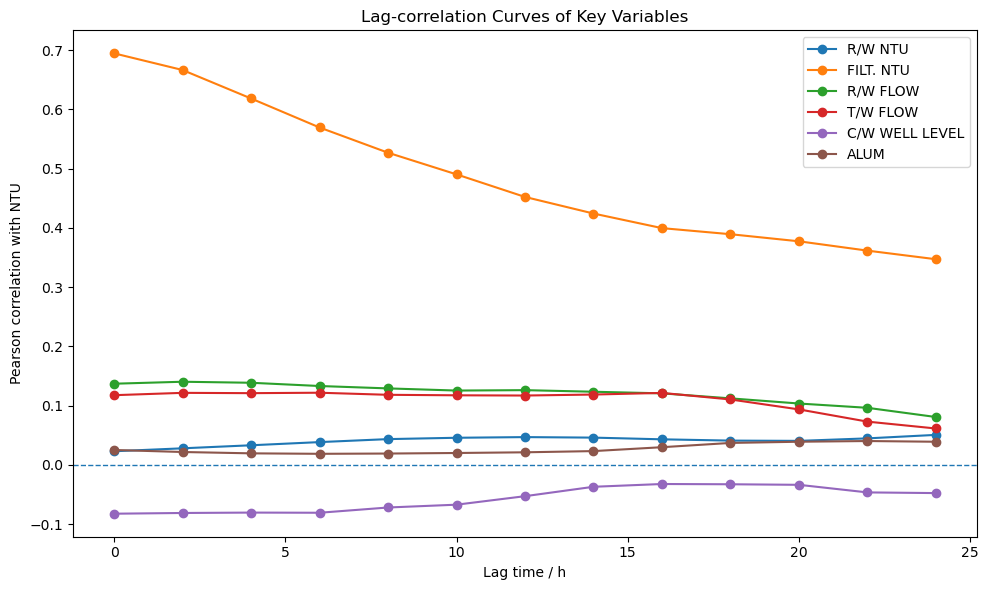

Saved: outputs\problem1\lag_correlation_curves_key_features.png


In [11]:
selected_plot_features = [
    "R/W NTU",
    "FILT. NTU",
    "R/W FLOW",
    "T/W FLOW",
    "C/W WELL LEVEL",
    "ALUM"
]

selected_plot_features = [f for f in selected_plot_features if f in candidate_features]

plt.figure(figsize=(10, 6))

for feature in selected_plot_features:
    temp = lag_corr_df[lag_corr_df["feature"] == feature]
    plt.plot(
        temp["lag_hours"],
        temp["pearson_corr"],
        marker="o",
        label=feature
    )

plt.axhline(0, linestyle="--", linewidth=1)
plt.xlabel("Lag time / h")
plt.ylabel("Pearson correlation with NTU")
plt.title("Lag-correlation Curves of Key Variables")
plt.legend()
plt.tight_layout()

fig_path = OUTPUT_DIR / "lag_correlation_curves_key_features.png"
plt.savefig(fig_path, dpi=300)
plt.show()

print("Saved:", fig_path)

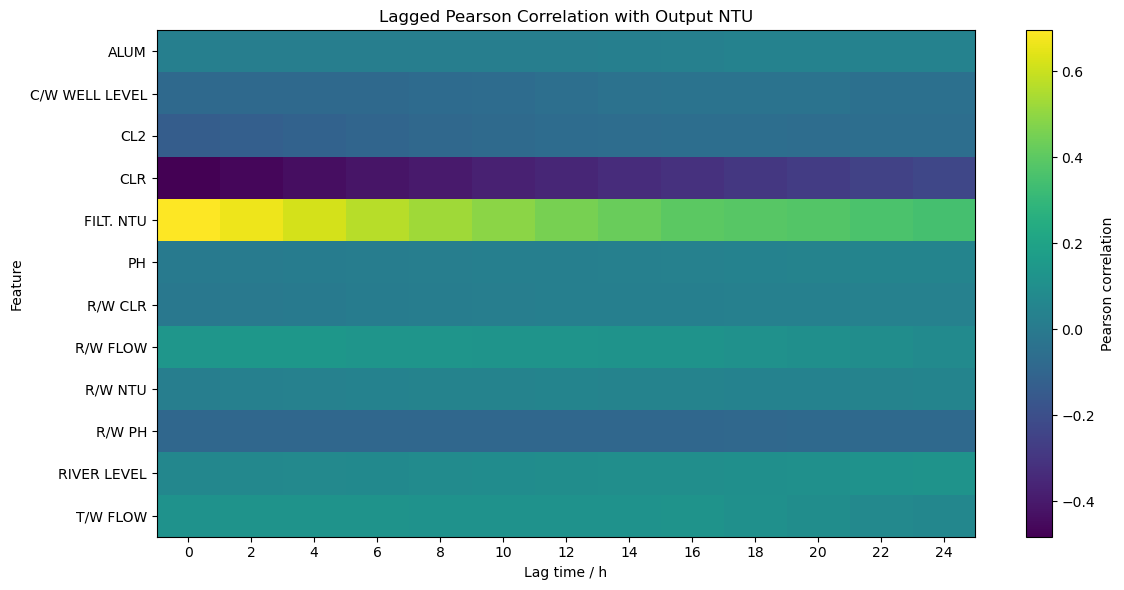

Saved: outputs\problem1\lag_pearson_heatmap.png


In [12]:
heatmap_data = lag_corr_df.pivot(
    index="feature",
    columns="lag_hours",
    values="pearson_corr"
)

plt.figure(figsize=(12, 6))
plt.imshow(heatmap_data, aspect="auto")
plt.colorbar(label="Pearson correlation")

plt.xticks(
    ticks=np.arange(len(heatmap_data.columns)),
    labels=heatmap_data.columns
)

plt.yticks(
    ticks=np.arange(len(heatmap_data.index)),
    labels=heatmap_data.index
)

plt.xlabel("Lag time / h")
plt.ylabel("Feature")
plt.title("Lagged Pearson Correlation with Output NTU")

plt.tight_layout()

heatmap_path = OUTPUT_DIR / "lag_pearson_heatmap.png"
plt.savefig(heatmap_path, dpi=300)
plt.show()

print("Saved:", heatmap_path)